# Palantir Trajectory Inference on LARRY Day-2 Data

Palantir (Setty et al. 2019) is a graph-based pseudotime algorithm that computes cell
fate probabilities along a learned diffusion manifold. As a single-snapshot method we
run it exclusively on day-2 cells and evaluate predicted fate probabilities against
ground-truth clonal lineage labels.

**Pipeline:**
1. Load preprocessed LARRY data (`larry_preprocessed.h5ad` from notebook 01)
2. Subset to day-2 cells and re-compute k-NN graph
3. Palantir diffusion maps → multiscale space
4. Select HSC/progenitor start cell
5. Run Palantir → pseudotime + branch probabilities
6. Visualize on UMAP
7. Evaluate against clonal ground-truth fate labels

## 1. Imports

In [3]:
%matplotlib inline

import sys
print(f"Python: {sys.executable}")

import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata
import palantir

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

PREPROCESSED_H5AD = "larry_preprocessed.h5ad"
OUTPUT_H5AD = "larry_day2_palantir.h5ad"
time_col = "Time point"
celltype_col = "Cell type annotation"
clone_col = "clone_idx"

print(f"Palantir version: {palantir.__version__}")

Python: c:\Users\judog\OneDrive\Documents\CLASSES\CS189\project\.venv\Scripts\python.exe
Palantir version: 1.4.4


## 2. Load preprocessed data

In [5]:
adata_full = anndata.read_h5ad(PREPROCESSED_H5AD)
print(adata_full)
print("\nobs columns:", list(adata_full.obs.columns))
print("obsm keys:  ", list(adata_full.obsm.keys()))

AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'connectivities', 'distances'

obs columns: ['Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr

## 3. Subset to day-2 cells

In [6]:
adata_d2 = adata_full[adata_full.obs[time_col] == 2].copy()
print(f"Day-2 cells: {adata_d2.n_obs:,} / {adata_full.n_obs:,}")

if clone_col in adata_d2.obs.columns:
    n_cloned = (adata_d2.obs[clone_col].fillna(-1).astype(int) >= 0).sum()
    print(f"  With clonal lineage info: {n_cloned:,} ({100*n_cloned/adata_d2.n_obs:.1f}%)")

if celltype_col in adata_d2.obs.columns:
    n_ct = adata_d2.obs[celltype_col].notna().sum()
    print(f"  With cell-type annotation: {n_ct:,}")
    if n_ct > 0:
        print(adata_d2.obs[celltype_col].value_counts())

Day-2 cells: 28,249 / 130,887
  With clonal lineage info: 4,638 (16.4%)
  With cell-type annotation: 28,249
Cell type annotation
Undifferentiated    25575
Neutrophil           1068
Monocyte              950
Baso                  187
Lymphoid              144
Erythroid             100
Meg                    97
Ccr7_DC                57
Mast                   40
pDC                    16
Eos                    15
Name: count, dtype: int64


## 4. k-NN graph, UMAP, and Palantir diffusion maps

Palantir requires:
1. `DM_EigenVectors` → from `run_diffusion_maps`
2. `DM_EigenVectors_multiscaled` → from `determine_multiscale_space`
3. Then `run_palantir` uses the multiscale eigenvectors.

In [7]:
print("Computing k-NN graph (n_neighbors=30, n_pcs=50)...")
sc.pp.neighbors(adata_d2, n_neighbors=30, n_pcs=50, use_rep="X_pca")

print("Computing UMAP for visualization...")
sc.tl.umap(adata_d2, random_state=42)

print("Running Palantir diffusion maps...")
palantir.utils.run_diffusion_maps(adata_d2, n_components=10, knn=30)

print("Computing multiscale diffusion space...")
palantir.utils.determine_multiscale_space(adata_d2)

print("Done.")
print("obsm keys:", list(adata_d2.obsm.keys()))

Computing k-NN graph (n_neighbors=30, n_pcs=50)...
Computing UMAP for visualization...
Running Palantir diffusion maps...
Computing multiscale diffusion space...
Done.
obsm keys: ['X_clone', 'X_pca', 'X_umap', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled']


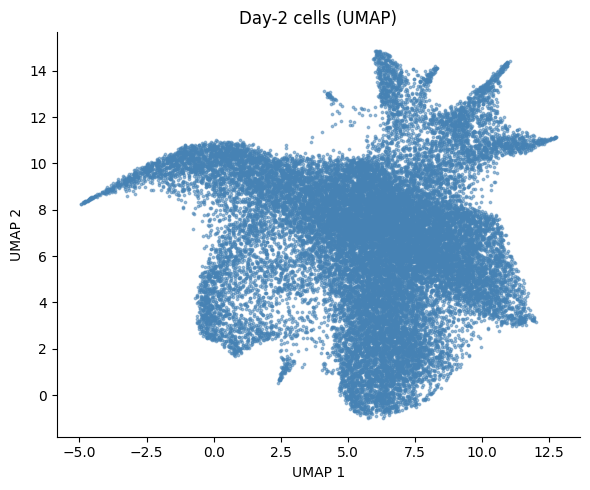

In [8]:
umap_d2 = adata_d2.obsm["X_umap"]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.5, color="steelblue")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Day-2 cells (UMAP)")
plt.tight_layout()
plt.show()

## 5. Select start cell

Select the day-2 cell with the highest composite HSC/LMPP marker score
(*Procr*, *Ly6a*, *Flt3*, *Gata2*, *Kit*, *Cd34*). Falls back to the cell nearest
to the PCA centroid if no markers are found.

In [ ]:
def get_gene_expr(adata, gene_name, prefer_layer="log1p_norm"):
    """Dense expression array for gene_name; prefers log1p_norm layer over scaled X."""
    hits = adata.var.index[adata.var.index == gene_name].tolist()
    if not hits:
        return None
    idx = adata.var.index.tolist().index(hits[0])
    if prefer_layer in adata.layers:
        col = adata.layers[prefer_layer][:, idx]
    else:
        col = adata.X[:, idx]
    return np.asarray(col.todense()).flatten() if sp.issparse(col) else np.asarray(col).flatten()


# HSC / LMPP markers (mouse); score on log-normalised counts so magnitude is preserved
hsc_markers = ["Procr", "Ly6a", "Flt3", "Gata2", "Kit", "Cd34"]
score = np.zeros(adata_d2.n_obs)
found_markers = []

for gene in hsc_markers:
    expr = get_gene_expr(adata_d2, gene)
    if expr is not None:
        mx = expr.max()
        if mx > 0:
            score += expr / mx
        found_markers.append(gene)

if found_markers:
    start_idx = int(np.argmax(score))
    start_cell = adata_d2.obs_names[start_idx]
    print(f"HSC markers found: {found_markers}")
    print(f"Start cell (max HSC score): {start_cell}  (index {start_idx})")
    ct = adata_d2.obs.loc[start_cell, celltype_col] if celltype_col in adata_d2.obs else "?"
    print(f"Cell type: {ct}")
else:
    pca_d2 = adata_d2.obsm["X_pca"][:, :10]
    centroid = pca_d2.mean(axis=0)
    start_idx = int(np.argmin(np.linalg.norm(pca_d2 - centroid, axis=1)))
    start_cell = adata_d2.obs_names[start_idx]
    print(f"No HSC markers found. Fallback to PCA centroid: {start_cell}")

HSC markers found: ['Procr', 'Ly6a', 'Flt3', 'Gata2', 'Kit', 'Cd34']
Start cell (max HSC score): 52785  (index 18261)
Cell type: Undifferentiated


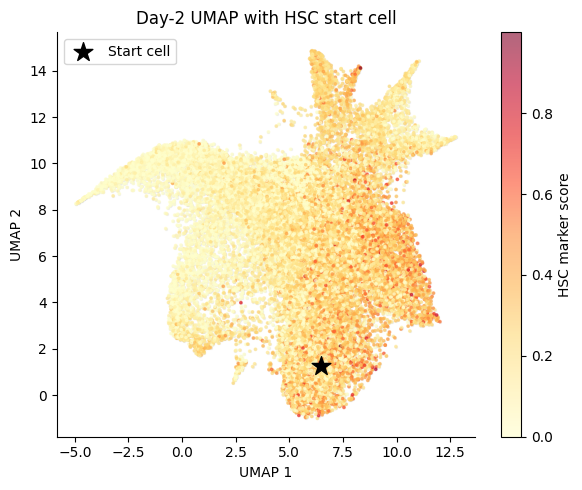

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=2, alpha=0.3, color="lightgray")

if found_markers:
    score_norm = (score - score.min()) / (score.max() - score.min() + 1e-9)
    sc_ = ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.6,
                     c=score_norm, cmap="YlOrRd")
    plt.colorbar(sc_, ax=ax, label="HSC marker score")

ax.scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1],
           s=200, color="black", marker="*", zorder=5, label="Start cell")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Day-2 UMAP with HSC start cell")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Run Palantir

In [ ]:
# ── Why we need explicit terminal states ─────────────────────────────────
# Palantir's automatic terminal-state detection uses Markov absorption on
# the diffusion map.  On day-2 LARRY data ~90 % of cells are "Undifferentiated",
# so there are no clear absorbing boundaries and the algorithm collapses to a
# single terminal state → every cell gets probability 1.0 for one branch,
# making evaluation meaningless.
#
# Fix: supply one representative cell per committed lineage as terminal states.
# palantir.utils.find_terminal_states picks the cell whose diffusion coordinates
# place it furthest along each lineage's diffusion component.

committed_lineages = [
    ct for ct in ['Neutrophil', 'Monocyte', 'Baso', 'Lymphoid', 'Erythroid', 'Meg']
    if ct in adata_d2.obs[celltype_col].values
]

terminal_states = palantir.utils.find_terminal_states(
    adata_d2,
    celltypes=committed_lineages,
    celltype_column=celltype_col,
    fallback_seed=42,
)
# Returns pd.Series: index = cell_name, value = lineage_name
print(f"Terminal states found: {len(terminal_states)}")
for cell, lineage in terminal_states.items():
    print(f"  {lineage:15s}  →  cell {cell}")

print(f"\nRunning Palantir (start: {start_cell}, {len(terminal_states)} terminal states, "
      f"num_waypoints=1200)...")

pr_res = palantir.core.run_palantir(
    adata_d2,
    start_cell,
    terminal_states=terminal_states,
    num_waypoints=1200,
    knn=30,
    n_jobs=1,
)

print("Palantir complete.")

pseudo_key = "palantir_pseudotime"
entropy_key = "palantir_entropy"
fate_prob_key = "palantir_fate_probabilities"

if pr_res is not None and hasattr(pr_res, "pseudotime"):
    adata_d2.obs[pseudo_key] = pr_res.pseudotime.reindex(adata_d2.obs_names).values
    adata_d2.obs[entropy_key] = pr_res.entropy.reindex(adata_d2.obs_names).values
    bp = pr_res.branch_probs.reindex(adata_d2.obs_names)
    adata_d2.obsm[fate_prob_key] = bp.values
    adata_d2.uns["palantir_branch_names"] = list(bp.columns)
    print("Results copied from pr_res object.")
elif pseudo_key in adata_d2.obs.columns:
    print("Results stored in adata by Palantir 1.x API.")
    cols_key = fate_prob_key + "_columns"
    if fate_prob_key in adata_d2.obsm and cols_key in adata_d2.uns:
        adata_d2.uns["palantir_branch_names"] = list(adata_d2.uns[cols_key])
else:
    print("WARNING: Could not locate Palantir results. Check the API.")

print("obs keys:  ", [c for c in adata_d2.obs.columns if "palantir" in c])
print("obsm keys: ", list(adata_d2.obsm.keys()))
print("# branches:", adata_d2.obsm.get(fate_prob_key, np.zeros((1, 1))).shape[1])
print("Branch names:", adata_d2.uns.get("palantir_branch_names"))

Using 17356 for cell type Neutrophil which is min in diffusion component 0.
Using 13942 for cell type Monocyte which is min in diffusion component 1.
Using 46555 for cell type Baso which is min in diffusion component 2.
Falling back to slow early cell detection.
Sampling and flocking waypoints...
Time for determining waypoints: 0.0004092574119567871 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.2511959473292033 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Using 48205 for cell type Lymphoid which is latest cell in Lymphoid when starting from 54437.
Using 17139 for cell type Erythroid which is max in diffusion component 0.
Falling back to slow early cel

## 7. Visualize Palantir results

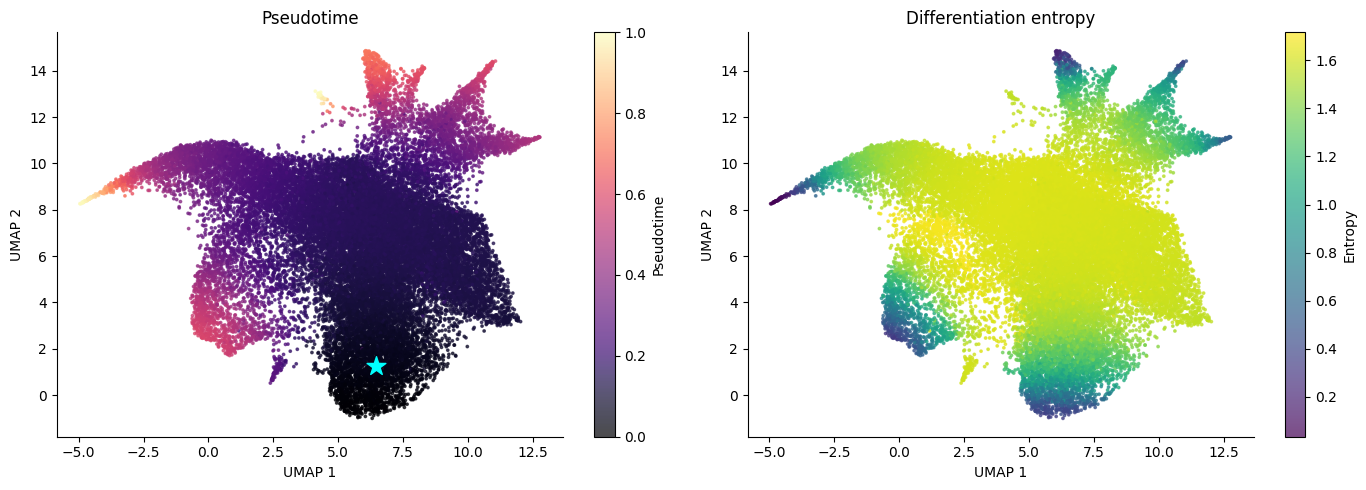

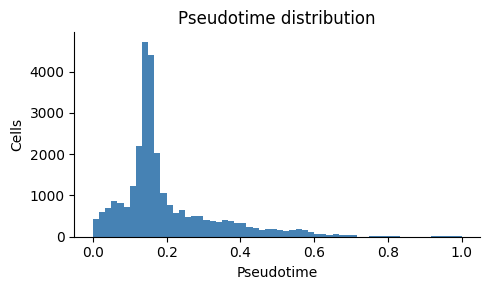

Pseudotime range: 0.000 – 1.000


In [ ]:
if pseudo_key in adata_d2.obs.columns:
    pseudo = adata_d2.obs[pseudo_key].values
    entropy  = adata_d2.obs[entropy_key].values if entropy_key in adata_d2.obs.columns else None

    ncols = 2 if entropy is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    sc0 = axes[0].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                          c=pseudo, cmap="magma", vmin=0, vmax=1)
    plt.colorbar(sc0, ax=axes[0], label="Pseudotime")
    axes[0].scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1],
                    s=200, color="cyan", marker="*", zorder=5)
    axes[0].set_title("Pseudotime")
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")

    if entropy is not None:
        sc1 = axes[1].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                              c=entropy, cmap="viridis")
        plt.colorbar(sc1, ax=axes[1], label="Entropy")
        axes[1].set_title("Differentiation entropy")
        axes[1].set_xlabel("UMAP 1")
        axes[1].set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(pseudo, bins=60, color="steelblue", edgecolor="none")
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Cells")
    ax.set_title("Pseudotime distribution")
    plt.tight_layout()
    plt.show()
    print(f"Pseudotime range: {pseudo.min():.3f} – {pseudo.max():.3f}")

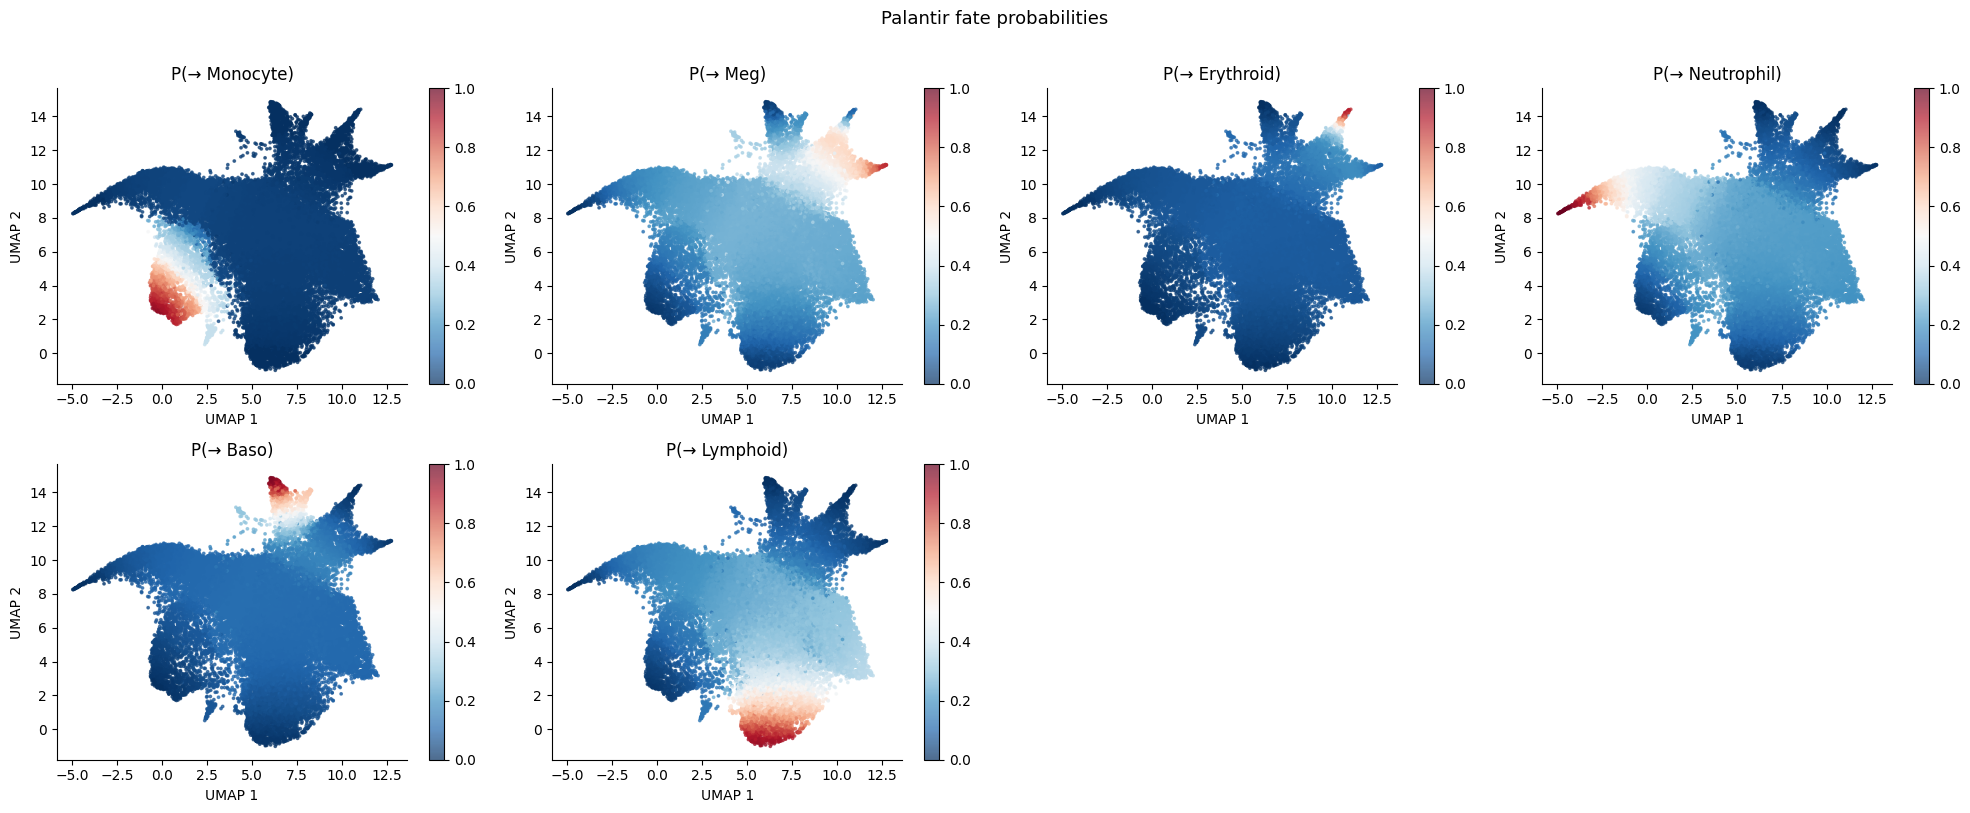

In [13]:
if fate_prob_key in adata_d2.obsm:
    bp_arr = adata_d2.obsm[fate_prob_key]
    branch_names = adata_d2.uns.get("palantir_branch_names",
                                     [f"Branch {i}" for i in range(bp_arr.shape[1])])
    n_branches = bp_arr.shape[1]
    ncols = min(n_branches, 4)
    nrows = (n_branches + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, (bname, ax) in enumerate(zip(branch_names, axes)):
        sc_ = ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                         c=bp_arr[:, i], cmap="RdBu_r", vmin=0, vmax=1)
        plt.colorbar(sc_, ax=ax)
        ax.set_title(f"P(→ {bname})")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    for ax in axes[n_branches:]:
        ax.set_visible(False)

    plt.suptitle("Palantir fate probabilities", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Branch probability matrix not found in adata_d2.obsm.")

## 8. Evaluate against clonal ground-truth fate labels

For day-2 cells with a clone assignment we know the observed fate from `fate_counts`.
We compare Palantir's branch probabilities to observed fate fractions using Pearson
correlation and, when Neutrophil / Monocyte are available, compute the standard
Weinreb 2020 Neu–Mono bias score.

In [14]:
# Fate fractions were computed in notebook 01 and saved as fate_frac_* columns
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
print(f"Fate fraction columns found: {len(fate_frac_cols)}")
for c in fate_frac_cols:
    print(f"  {c}")

has_fate = pd.Series(False, index=adata_d2.obs_names)
if fate_frac_cols:
    has_fate = adata_d2.obs[fate_frac_cols[0]].notna()
    n = has_fate.sum()
    print(f"\nDay-2 cells with ground-truth fate fractions: {n:,} / {adata_d2.n_obs:,}")
    if n > 0:
        print("\nMean fate fractions across cloned day-2 cells:")
        means = adata_d2.obs.loc[has_fate, fate_frac_cols].mean().sort_values(ascending=False)
        print(means.rename(lambda c: c.replace("fate_frac_", "")).round(3).to_string())
else:
    print("No fate_frac_* columns found in adata_d2.obs.")
    print("Re-run notebook 01 (including the new '7b. Clonal fate fractions' cell) "
          "to generate them, then reload the saved h5ad here.")

Fate fraction columns found: 11
  fate_frac_Baso
  fate_frac_Ccr7_DC
  fate_frac_Eos
  fate_frac_Erythroid
  fate_frac_Lymphoid
  fate_frac_Mast
  fate_frac_Meg
  fate_frac_Monocyte
  fate_frac_Neutrophil
  fate_frac_Undifferentiated
  fate_frac_pDC

Day-2 cells with ground-truth fate fractions: 2,621 / 28,249

Mean fate fractions across cloned day-2 cells:
Undifferentiated    0.387
Neutrophil          0.231
Monocyte            0.205
Baso                0.084
Meg                 0.033
Lymphoid            0.025
Mast                0.017
Erythroid           0.006
Eos                 0.006
Ccr7_DC             0.005
pDC                 0.002


In [15]:
fate_df_norm = None

if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    # Drop lineages with zero observed clonal output (avoid degenerate correlations)
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    # Friendly column names
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]
    print(f"Ground-truth fate matrix: {fate_df_norm.shape[0]:,} cells × {fate_df_norm.shape[1]} lineages")
    print(f"Lineages: {list(fate_df_norm.columns)}")
    print(fate_df_norm.head(3).round(3))
else:
    print("Skipping: no fate fractions available (see cell above).")

Ground-truth fate matrix: 2,621 cells × 11 lineages
Lineages: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']
       Baso  Ccr7_DC  Eos  Erythroid  Lymphoid  Mast  Meg  Monocyte  \
13199   0.0      0.0  0.0        0.0       0.0   0.0  0.0     0.571   
13210   0.0      0.0  0.0        0.0       0.0   0.0  0.0     0.000   
13226   0.0      0.0  0.0        0.0       0.0   0.0  1.0     0.000   

       Neutrophil  Undifferentiated  pDC  
13199         0.0             0.429  0.0  
13210         1.0             0.000  0.0  
13226         0.0             0.000  0.0  


Cells with both Palantir probs and fate labels: 2,621

Pearson r (observed fate fraction × Palantir branch probability):
                  Monocyte    Meg  Erythroid  Neutrophil   Baso  Lymphoid
Baso                -0.056  0.094      0.079      -0.299  0.507    -0.283
Ccr7_DC              0.210 -0.077     -0.065      -0.043 -0.042    -0.012
Eos                 -0.021  0.044      0.032      -0.041  0.069    -0.057
Erythroid           -0.039  0.244      0.283      -0.150 -0.006    -0.131
Lymphoid            -0.042 -0.159     -0.133      -0.115 -0.086     0.348
Mast                -0.060  0.088      0.073      -0.221  0.366    -0.207
Meg                 -0.065  0.499      0.478      -0.299 -0.000    -0.264
Monocyte             0.232 -0.176     -0.157       0.121 -0.146     0.048
Neutrophil          -0.006 -0.148     -0.132       0.544 -0.129    -0.118
Undifferentiated    -0.131  0.034      0.009      -0.159 -0.153     0.317
pDC                 -0.012 -0.009     -0.009      -0.030 -0.017  

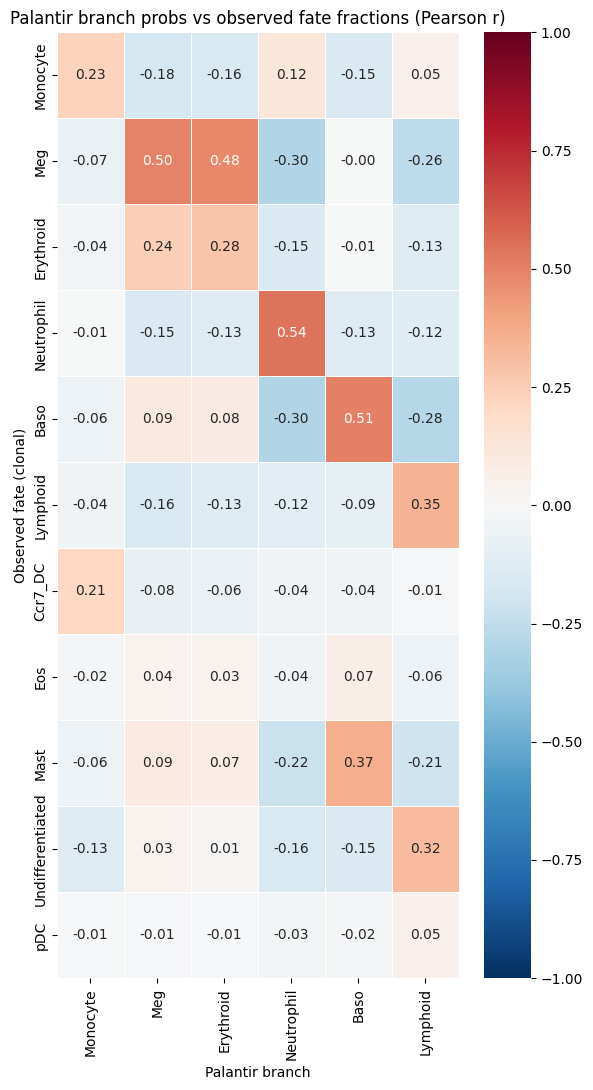

In [ ]:
corr_df = None

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names = adata_d2.uns.get(
        "palantir_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names,
    )

    common = fate_df_norm.index.intersection(bp_df.index)
    print(f"Cells with both Palantir probs and fate labels: {len(common):,}")
    fate_sub = fate_df_norm.loc[common]
    bp_sub   = bp_df.loc[common]

    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)

    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)
    print("\nPearson r (observed fate fraction × Palantir branch probability):")
    print(corr_df.round(3).to_string())

    # Reorder rows: identified lineages aligned to diagonal, unidentified appended after
    identified = [c for c in corr_df.columns if c in corr_df.index]
    unidentified = [r for r in corr_df.index if r not in corr_df.columns]
    corr_df_plot = corr_df.loc[identified + unidentified]

    fig_w = max(6, len(bp_sub.columns))
    fig_h = max(4, len(fate_sub.columns))
    fig_h = max(4, len(corr_df_plot))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(corr_df_plot, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title("Palantir branch probs vs observed fate fractions (Pearson r)")
    ax.set_xlabel("Palantir branch")
    ax.set_ylabel("Observed fate (clonal)")
    plt.tight_layout()
    plt.savefig("palantir_corr_heatmap.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping correlation heatmap: no fate fractions or branch probs available.")

>##### Observe diagonal for the first 6 rows/columns; Weinreb 2020 reports r ≈ 0.3–0.4 for methods that work.

Neu–Mono bias  Pearson r: 0.3047  (p=3.63e-34)
(Palantir branch 'Neutrophil' used as Neutrophil predictor)


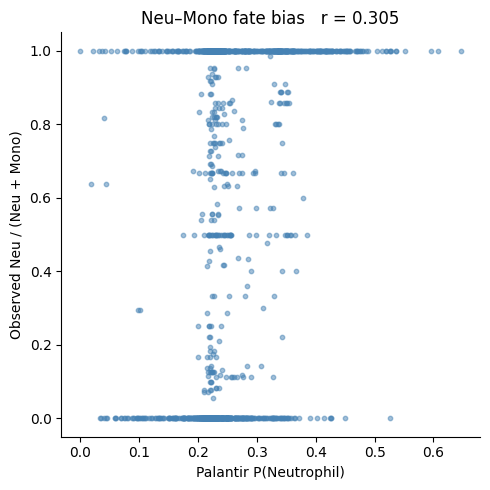

In [ ]:
# Weinreb-style Neutrophil–Monocyte bias score
# Both column names use underscores from the fate_frac_* convention
NEU_KEYS = ["Neutrophil", "Neu"]
MONO_KEYS = ["Monocyte",   "Mono"]

if fate_df_norm is not None and corr_df is not None:
    neu_col = next((c for c in fate_df_norm.columns if c in NEU_KEYS),  None)
    mono_col = next((c for c in fate_df_norm.columns if c in MONO_KEYS), None)

    if neu_col and mono_col:
        denom = fate_sub[neu_col] + fate_sub[mono_col]
        obs_bias = (fate_sub[neu_col] / denom.replace(0, np.nan)).dropna()

        best_branch = corr_df.loc[neu_col].abs().idxmax()
        pred_bias = bp_sub.loc[obs_bias.index, best_branch].values
        r, p = stats.pearsonr(pred_bias, obs_bias.values)

        print(f"Neu–Mono bias  Pearson r: {r:.4f}  (p={p:.2e})")
        print(f"(Palantir branch '{best_branch}' used as Neutrophil predictor)")

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(pred_bias, obs_bias.values, s=10, alpha=0.5, color="steelblue")
        ax.set_xlabel(f"Palantir P({best_branch})")
        ax.set_ylabel("Observed Neu / (Neu + Mono)")
        ax.set_title(f"Neu–Mono fate bias   r = {r:.3f}")
        plt.tight_layout()
        plt.savefig("palantir_neu_mono_bias.png", dpi=80, bbox_inches="tight")
        plt.show()
    else:
        print(f"Neu/Mono columns not in fate_df_norm. Available: {list(fate_df_norm.columns)}")
else:
    print("Skipping: correlation matrix not available.")

>##### Interpretation: among day-2 cells with clone assignments, many clones produce both Neutrophils and Monocytes at day 4/6. Some clones produce mostly Neutrophils, some mostly Monocytes. Can Palantir can detect it from gene expression alone? <br> Y axis - Neu / (Neu + Mono); for each cloned day-2 cell, what fraction of its clone's Neu+Mono descendants ended up as Neutrophils? 0 = pure Monocyte fate, 1 = pure Neutrophil fate. <br> X axis - Palantir's P(Neutrophil branch) for that same cell. <br> We expect points trending upward - cells Palantir assigns high P(Neutrophil) should also have high observed Neu fraction.

## 8c. Wasserstein-1 distance (per-cell fate distribution comparison)

Earth Mover's Distance between Palantir's predicted fate distribution and the observed clonal fate distribution, restricted to lineages present in both (the 6 Palantir branches). Lower = better. Lineages are treated as points on a 1-D axis (alphabetical order); cost of moving mass between adjacent lineages is 1.

Shared lineages (Palantir branches ∩ observed fate labels): ['Baso', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']
  (6 of 11 observed lineages covered by Palantir branches)

Wasserstein-1 distance (6 shared lineages, 2,013 cells):
  Mean:    1.7978
  Median:  1.7771
  Std:     0.5184


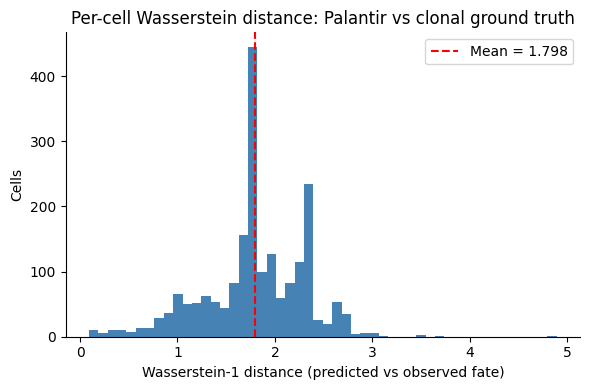

In [5]:
from scipy.stats import wasserstein_distance as _w1

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names_wd = adata_d2.uns.get(
        "palantir_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df_wd = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names_wd,
    )

    shared = sorted(set(fate_df_norm.columns) & set(bp_df_wd.columns))
    print(f"Shared lineages (Palantir branches ∩ observed fate labels): {shared}")
    print(f"  ({len(shared)} of {len(fate_df_norm.columns)} observed lineages covered by Palantir branches)")

    common_wd = fate_df_norm.index.intersection(bp_df_wd.index)
    fate_sub_wd = fate_df_norm.loc[common_wd, shared].values.astype(float)
    bp_sub_wd = bp_df_wd.loc[common_wd, shared].values.astype(float)
    lineage_vals = np.arange(len(shared), dtype=float)

    per_cell_wd = []
    for obs_vec, pred_vec in zip(fate_sub_wd, bp_sub_wd):
        obs_s, pred_s = obs_vec.sum(), pred_vec.sum()
        if obs_s > 0 and pred_s > 0:
            per_cell_wd.append(
                _w1(lineage_vals, lineage_vals,
                    obs_vec / obs_s, pred_vec / pred_s)
            )

    per_cell_wd = np.array(per_cell_wd)
    print(f"\nWasserstein-1 distance ({len(shared)} shared lineages, {len(per_cell_wd):,} cells):")
    print(f"  Mean:    {per_cell_wd.mean():.4f}")
    print(f"  Median:  {np.median(per_cell_wd):.4f}")
    print(f"  Std:     {per_cell_wd.std():.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_wd, bins=50, color="steelblue", edgecolor="none")
    ax.axvline(per_cell_wd.mean(), color="red", linestyle="--",
               label=f"Mean = {per_cell_wd.mean():.3f}")
    ax.set_xlabel("Wasserstein-1 distance (predicted vs observed fate)")
    ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein distance: Palantir vs clonal ground truth")
    ax.legend()
    plt.tight_layout()
    plt.savefig("palantir_wasserstein.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: fate fractions or branch probabilities not available.")

>#### Note: Not a great evaluation metric, since alphabetical ordering of lineages is arbitrary and does not reflect biological differences.

## 8d. UMAP-distance Wasserstein

Same per-cell EMD as 8c but uses pairwise Euclidean distances between terminal-state UMAP coordinates as the cost matrix, which is biologically more meaningful than alphabetical lineage ordering. Lineages that are close in UMAP space (e.g. Neutrophil and Monocyte) incur a lower transport cost than those far apart (e.g. Lymphoid and Erythroid).

Shared lineages: ['Baso', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']

Normalized UMAP distance cost matrix between terminal states:
             Baso  Erythroid  Lymphoid    Meg  Monocyte  Neutrophil
Baso        0.000      0.275     0.890  0.431     0.782       0.713
Erythroid   0.275      0.000     0.907  0.207     0.915       0.947
Lymphoid    0.890      0.907     0.000  0.785     0.388       0.792
Meg         0.431      0.207     0.785  0.000     0.877       1.000
Monocyte    0.782      0.915     0.388  0.877     0.000       0.419
Neutrophil  0.713      0.947     0.792  1.000     0.419       0.000

UMAP-distance Wasserstein (6 lineages, 2,013 cells):
  Mean:    0.5210
  Median:  0.5634
  Std:     0.1393


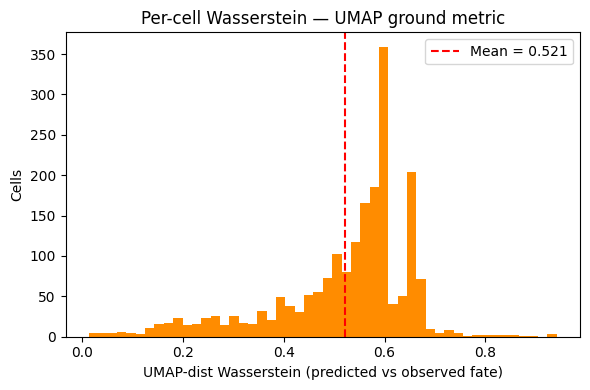

In [ ]:
from scipy.optimize import linprog
from scipy.spatial.distance import cdist as _cdist

def _emd_cost_matrix(p, q, C):
    """Exact EMD between distributions p, q with cost matrix C. Solved as LP."""
    K = len(p)
    A_eq = np.zeros((2 * K, K * K))
    b_eq = np.zeros(2 * K)
    for i in range(K):
        A_eq[i, i * K:(i + 1) * K] = 1.0
        b_eq[i] = p[i]
    for j in range(K):
        A_eq[K + j, j::K] = 1.0
        b_eq[K + j] = q[j]
    res = linprog(C.flatten(), A_eq=A_eq, b_eq=b_eq,
                  bounds=[(0, None)] * (K * K), method="highs")
    return float(res.fun) if res.success else np.nan

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names_ud = adata_d2.uns.get(
        "palantir_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df_ud = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names_ud,
    )
    shared_ud = sorted(set(fate_df_norm.columns) & set(bp_df_ud.columns))
    print(f"Shared lineages: {shared_ud}")

    # Terminal cell for each branch = cell with highest branch probability
    obs_name_arr = np.array(adata_d2.obs_names)
    terminal_umap_coords = np.array([
        adata_d2.obsm["X_umap"][np.where(obs_name_arr == bp_df_ud[b].idxmax())[0][0]]
        for b in shared_ud
    ])

    C_umap = _cdist(terminal_umap_coords, terminal_umap_coords)
    C_umap /= C_umap.max() if C_umap.max() > 0 else 1.0
    print("\nNormalized UMAP distance cost matrix between terminal states:")
    print(pd.DataFrame(C_umap.round(3), index=shared_ud, columns=shared_ud).to_string())

    common_ud = fate_df_norm.index.intersection(bp_df_ud.index)
    fate_sub_ud = fate_df_norm.loc[common_ud, shared_ud].values.astype(float)
    bp_sub_ud = bp_df_ud.loc[common_ud, shared_ud].values.astype(float)

    per_cell_umap_wd = []
    for obs_vec, pred_vec in zip(fate_sub_ud, bp_sub_ud):
        os_, ps_ = obs_vec.sum(), pred_vec.sum()
        if os_ > 0 and ps_ > 0:
            per_cell_umap_wd.append(_emd_cost_matrix(obs_vec / os_, pred_vec / ps_, C_umap))

    per_cell_umap_wd = np.array(per_cell_umap_wd)
    print(f"\nUMAP-distance Wasserstein ({len(shared_ud)} lineages, {len(per_cell_umap_wd):,} cells):")
    print(f"  Mean:    {per_cell_umap_wd.mean():.4f}")
    print(f"  Median:  {np.median(per_cell_umap_wd):.4f}")
    print(f"  Std:     {per_cell_umap_wd.std():.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_umap_wd, bins=50, color="darkorange", edgecolor="none")
    ax.axvline(per_cell_umap_wd.mean(), color="red", linestyle="--",
               label=f"Mean = {per_cell_umap_wd.mean():.3f}")
    ax.set_xlabel("UMAP-dist Wasserstein (predicted vs observed fate)")
    ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein — UMAP ground metric")
    ax.legend()
    plt.tight_layout()
    plt.savefig("palantir_wasserstein_umap.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: fate fractions or branch probabilities not available.")

## 8e. Pseudotime-distance Wasserstein

Uses each branch terminal state's Palantir pseudotime as its 1-D coordinate. Moving mass between two fates costs their pseudotime difference - unlike the alphabetical ordering in 8c, fates that share a similar differentiation depth are assigned a low cost even if their names are far apart alphabetically.

Terminal state pseudotime positions:
  Baso             0.7158
  Erythroid        0.5993
  Lymphoid         0.0000
  Meg              0.4831
  Monocyte         0.5877
  Neutrophil       0.9925

Pseudotime-distance Wasserstein (6 lineages, 2,013 cells):
  Mean:    0.3251
  Median:  0.3140
  Std:     0.1143


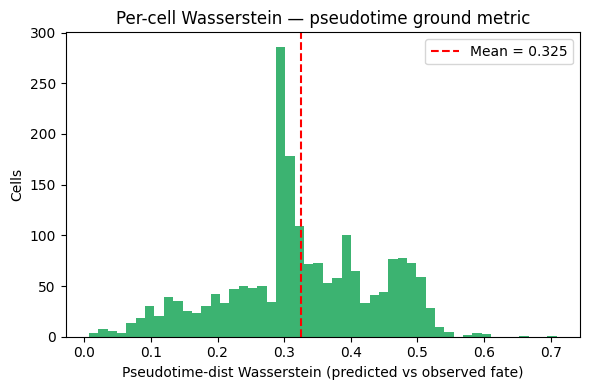

In [ ]:
from scipy.stats import wasserstein_distance as _w1_pt

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm and pseudo_key in adata_d2.obs:
    branch_names_pt = adata_d2.uns.get(
        "palantir_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    bp_df_pt = pd.DataFrame(
        adata_d2.obsm[fate_prob_key],
        index=adata_d2.obs_names,
        columns=branch_names_pt,
    )
    shared_pt = sorted(set(fate_df_norm.columns) & set(bp_df_pt.columns))

    # Terminal cell for each branch = argmax of branch probability column
    obs_name_arr_pt = np.array(adata_d2.obs_names)
    terminal_pt_vals = {
        b: float(adata_d2.obs[pseudo_key].iloc[
            np.where(obs_name_arr_pt == bp_df_pt[b].idxmax())[0][0]
        ])
        for b in shared_pt
    }
    pt_positions = np.array([terminal_pt_vals[b] for b in shared_pt])
    print("Terminal state pseudotime positions:")
    for b, pt in zip(shared_pt, pt_positions):
        print(f"  {b:15s}  {pt:.4f}")

    common_pt = fate_df_norm.index.intersection(bp_df_pt.index)
    fate_sub_pt = fate_df_norm.loc[common_pt, shared_pt].values.astype(float)
    bp_sub_pt = bp_df_pt.loc[common_pt, shared_pt].values.astype(float)

    per_cell_pt_wd = []
    for obs_vec, pred_vec in zip(fate_sub_pt, bp_sub_pt):
        os_, ps_ = obs_vec.sum(), pred_vec.sum()
        if os_ > 0 and ps_ > 0:
            per_cell_pt_wd.append(
                _w1_pt(pt_positions, pt_positions, obs_vec / os_, pred_vec / ps_)
            )

    per_cell_pt_wd = np.array(per_cell_pt_wd)
    print(f"\nPseudotime-distance Wasserstein ({len(shared_pt)} lineages, {len(per_cell_pt_wd):,} cells):")
    print(f"  Mean:    {per_cell_pt_wd.mean():.4f}")
    print(f"  Median:  {np.median(per_cell_pt_wd):.4f}")
    print(f"  Std:     {per_cell_pt_wd.std():.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_pt_wd, bins=50, color="mediumseagreen", edgecolor="none")
    ax.axvline(per_cell_pt_wd.mean(), color="red", linestyle="--",
               label=f"Mean = {per_cell_pt_wd.mean():.3f}")
    ax.set_xlabel("Pseudotime-dist Wasserstein (predicted vs observed fate)")
    ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein — pseudotime ground metric")
    ax.legend()
    plt.tight_layout()
    plt.savefig("palantir_wasserstein_pseudotime.png", dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: fate fractions, branch probs, or pseudotime not available.")

## 9. Save

In [18]:
print(f"Saving to {OUTPUT_H5AD} ...")
adata_d2.write_h5ad(OUTPUT_H5AD)

result_cols = [c for c in adata_d2.obs.columns
               if "palantir" in c or c in [time_col, clone_col, celltype_col]]
adata_d2.obs[result_cols].to_csv("palantir_day2_results.csv")
print("CSV saved to palantir_day2_results.csv")

Saving to larry_day2_palantir.h5ad ...
CSV saved to palantir_day2_results.csv


In [19]:
print("=" * 55)
print("PALANTIR ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Day-2 cells:    {adata_d2.n_obs:,}")
print(f"  Start cell:     {start_cell}")
if pseudo_key in adata_d2.obs.columns:
    pt = adata_d2.obs[pseudo_key]
    print(f"  Pseudotime:     {pt.min():.3f} – {pt.max():.3f}")
if fate_prob_key in adata_d2.obsm:
    print(f"  # branches:     {adata_d2.obsm[fate_prob_key].shape[1]}")
    print(f"  Branch names:   {adata_d2.uns.get('palantir_branch_names', 'N/A')}")
print(f"  Output h5ad:    {OUTPUT_H5AD}")

PALANTIR ANALYSIS COMPLETE
  Day-2 cells:    28,249
  Start cell:     52785
  Pseudotime:     0.000 – 1.000
  # branches:     6
  Branch names:   ['Monocyte', 'Meg', 'Erythroid', 'Neutrophil', 'Baso', 'Lymphoid']
  Output h5ad:    larry_day2_palantir.h5ad


---
## Eval-only checkpoint

Run the cell below on a **fresh kernel** to restore all variables needed by the section 8 eval cells (Pearson r heatmap, Neu–Mono bias, Wasserstein distance) without re-running the full Palantir pipeline. Requires `larry_day2_palantir.h5ad` to exist (produced by the Save cell above).

In [1]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

warnings.filterwarnings("ignore")

# ── Constants ──────────────────────────────────────────────────────────────────
OUTPUT_H5AD = "larry_day2_palantir.h5ad"
time_col = "Time point"
celltype_col = "Cell type annotation"
clone_col = "clone_idx"
pseudo_key = "palantir_pseudotime"
entropy_key = "palantir_entropy"
fate_prob_key = "palantir_fate_probabilities"

# ── Load saved AnnData (contains Palantir results in obs/obsm/uns) ─────────────
print(f"Loading {OUTPUT_H5AD} ...")
adata_d2 = anndata.read_h5ad(OUTPUT_H5AD)
print(adata_d2)

# ── Reconstruct fate-fraction variables ────────────────────────────────────────
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
has_fate = (
    adata_d2.obs[fate_frac_cols[0]].notna()
    if fate_frac_cols
    else pd.Series(False, index=adata_d2.obs_names)
)

fate_df_norm = None
if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]

# ── Reconstruct branch-probability DataFrame + intersection subsets ─────────────
branch_names = (
    adata_d2.uns.get(
        "palantir_branch_names",
        [f"Branch_{i}" for i in range(adata_d2.obsm[fate_prob_key].shape[1])]
    )
    if fate_prob_key in adata_d2.obsm else []
)
bp_df = (
    pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names, columns=branch_names)
    if fate_prob_key in adata_d2.obsm else None
)

corr_df = fate_sub = bp_sub = None
if fate_df_norm is not None and bp_df is not None:
    common = fate_df_norm.index.intersection(bp_df.index)
    fate_sub = fate_df_norm.loc[common]
    bp_sub = bp_df.loc[common]

    # Pearson r matrix — needed by the Neu-Mono bias cell
    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)
    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)

print("\nAll eval-metric variables restored:")
print(f"  adata_d2     {adata_d2.n_obs:,} cells, obsm keys: {list(adata_d2.obsm.keys())}")
print(f"  fate_df_norm {fate_df_norm.shape if fate_df_norm is not None else None}")
print(f"  fate_sub     {fate_sub.shape if fate_sub is not None else None}")
print(f"  bp_sub       {bp_sub.shape if bp_sub is not None else None}")
print(f"  corr_df      {corr_df.shape if corr_df is not None else None}")
print(f"  branch_names {branch_names}")
print("\nReady — run any eval cell in section 8.")

Loading larry_day2_palantir.h5ad ...
AnnData object with n_obs × n_vars = 28249 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC', 'palantir_pseudotime', 'palantir_entropy'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'hvg', 'log1p', 'neighbors', 'palantir_branch_names', 'palantir_waypoints', 'pca', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_clone', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 